In [27]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [28]:
clock_img = cv.imread("../../../class.vision/images/clock.jpg")

In [125]:
def to_gray(img):
    return cv.cvtColor(img, cv.COLOR_BGR2GRAY)

def blur(img):
    return cv.GaussianBlur(img, (5,5), 0)

def closing(img):
    se = cv.getStructuringElement(cv.MORPH_RECT, (3,3))
    return cv.morphologyEx(img, cv.MORPH_CLOSE, se)

def opening(img):
    se = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3,3))
    return cv.morphologyEx(img, cv.MORPH_OPEN, se)

def to_binary(img):
    # return cv.adaptiveThreshold(to_gray(img),255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY_INV, 11, 2)
    return cv.threshold(to_gray(img), 127, 255, cv.THRESH_BINARY_INV)[1]

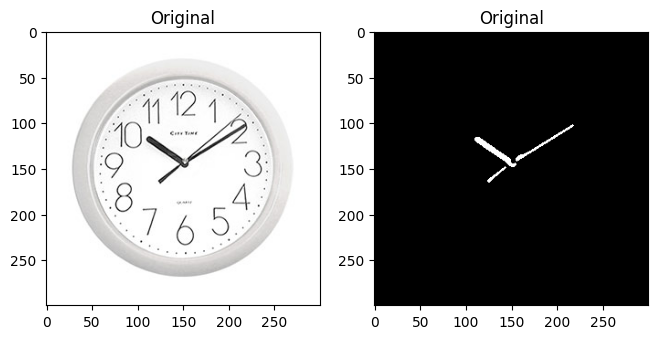

In [127]:
binary = to_binary(blur(clock_img))
opened = opening(binary)
plt.figure(figsize=[12,7])
plt.subplot(131);plt.imshow(clock_img[...,::-1]);plt.title("Original");
plt.subplot(132);plt.imshow(binary, cmap='gray');plt.title("Binary");
plt.subplot(132);plt.imshow(opened, cmap='gray');plt.title("Original");

Lines number:  4


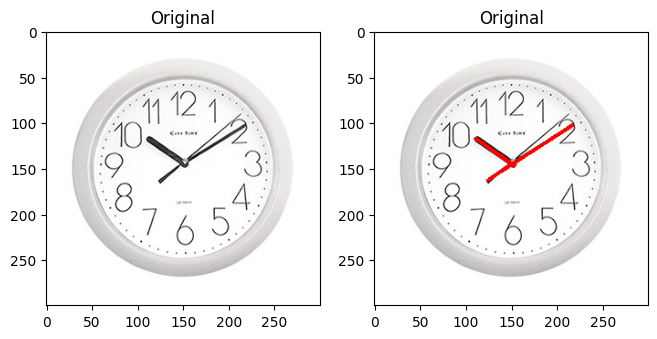

In [219]:
lines = cv.HoughLinesP(opened, 1, np.pi/180, 50, minLineLength=20, maxLineGap=20)

draw_img = clock_img.copy()

X1 = []
Y1 = []
X2 = []
Y2 = []

for [line] in lines:
    X1.append(line[0])
    Y1.append(line[1])
    X2.append(line[2])
    Y2.append(line[3])
    cv.line(draw_img, (line[0],line[1]), (line[2],line[3]), (0,0,255), 2)

print("Lines number: ", len(lines))

plt.figure(figsize=[12,7])
plt.subplot(131);plt.imshow(clock_img[...,::-1]);plt.title("Original");
plt.subplot(132);plt.imshow(draw_img[...,::-1]);plt.title("Original");

In [220]:
np.column_stack((X1,Y1, X2, Y2))

array([[124, 163, 217, 103],
       [126, 161, 217, 102],
       [111, 117, 154, 147],
       [110, 117, 153, 148]], dtype=int32)

[[110 117 153 147]
 [125 162 217 102]]


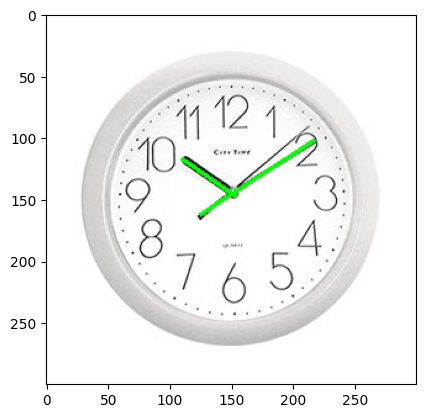

In [224]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2)

model.fit(np.column_stack((X1,Y1, X2, Y2)))


draw_img = clock_img.copy()
lines = model.cluster_centers_.astype(int)
print(lines)
for line in lines:
    cv.line(draw_img, (line[0],line[1]), (line[2],line[3]), (0,255,0), 2)

plt.imshow(draw_img[...,::-1])

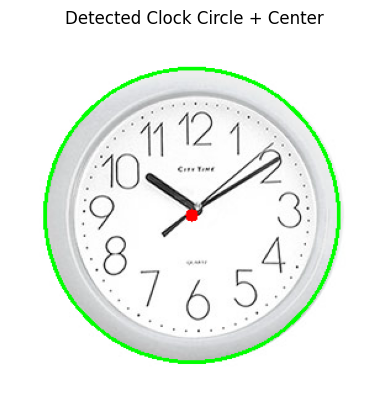

In [214]:
img = clock_img.copy()
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray = cv.medianBlur(gray, 5)

gray_blur = cv.medianBlur(gray, 5)

circles = cv.HoughCircles(
    gray_blur,
    cv.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=100,
    maxRadius=0
)

circle_vis = clock_img.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))
    cx, cy, r = circles[0][0]
    cv.circle(circle_vis, (cx, cy), r, (0,255,0), 2)
    cv.circle(circle_vis, (cx, cy), 5, (255,0,0), -1)
else:
    raise Exception("Circle not detected")

plt.figure()
plt.title("Detected Clock Circle + Center")
plt.imshow(circle_vis)
plt.axis("off")
plt.show()

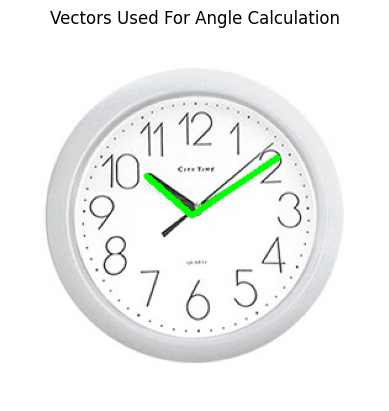

In [226]:
angles_lengths = []
angle_vis = clock_img.copy()

for line in lines:
    x1, y1, x2, y2 = line

    d1 = np.hypot(x1 - cx, y1 - cy)
    d2 = np.hypot(x2 - cx, y2 - cy)

    if d1 > d2:
        xt, yt = x1, y1
        length = d1
    else:
        xt, yt = x2, y2
        length = d2

    dx = xt - cx
    dy = cy - yt  # invert Y axis

    angle = np.arctan2(dx, dy)
    angle_deg = np.degrees(angle)
    if angle_deg < 0:
        angle_deg += 360

    angles_lengths.append((angle_deg, length))

    # draw vector from center to tip
    cv.line(angle_vis, (cx, cy), (xt, yt), (0,255,0), 3)

plt.figure()
plt.title("Vectors Used For Angle Calculation")
plt.imshow(angle_vis)
plt.axis("off")
plt.show()


In [227]:
angles_lengths.sort(key=lambda x: x[1], reverse=True)

minute_angle = angles_lengths[0][0]
hour_angle = angles_lengths[1][0]

minute = int(round(minute_angle / 6)) % 60
hour = int(hour_angle / 30) % 12
if hour == 0:
    hour = 12

print("Minute angle:", minute_angle)
print("Hour angle:", hour_angle)
print(f"Detected time: {hour:02d}:{minute:02d}")

Minute angle: 56.12146019489035
Hour angle: 310.8553762588957
Detected time: 10:09
